<a href="https://colab.research.google.com/github/eeolga/article/blob/main/144_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

# Load the Excel file
df = pd.read_excel('/content/144.xlsx')

# Display the first 5 rows of the DataFrame
display(df.head())

,code,level_scaled,"difficulty\nweight,\nWDi",WLi,"time, Tresource","time weight norm, \nWTi","success indicator,\nSi"
0,1,0.01,0.007246,0.004677,4.521739,2.26087,1.133287
1,2,0.01,0.007246,0.001961,4.521739,2.26087,1.132472
2,3,0.01,0.007246,0.000226,4.521739,2.26087,1.131952
3,4,0.01,0.007246,0.002942,4.521739,2.26087,1.132767
4,5,0.01,0.007246,0.000490,4.521739,2.26087,1.132031


In [2]:
# Display information about the DataFrame, including data types and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46 entries, 0 to 45
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   code                     46 non-null     int64  
 1   level_scaled             46 non-null     float64
 2   difficulty
weight,
WDi   46 non-null     float64
 3   WLi                      46 non-null     float64
 4   time, Tresource          46 non-null     float64
 5   time weight norm, 
WTi   46 non-null     float64
 6   success indicator,
Si    46 non-null     float64
dtypes: float64(6), int64(1)
memory usage: 2.6 KB


In [3]:
df.columns = df.columns.str.replace(r'[\n,]', '', regex=True).str.strip().str.replace(r'\s+', '_', regex=True).str.lower()

display(df.head())

,code,level_scaled,difficultyweightwdi,wli,time_tresource,time_weight_norm_wti,success_indicatorsi
0,1,0.01,0.007246,0.004677,4.521739,2.26087,1.133287
1,2,0.01,0.007246,0.001961,4.521739,2.26087,1.132472
2,3,0.01,0.007246,0.000226,4.521739,2.26087,1.131952
3,4,0.01,0.007246,0.002942,4.521739,2.26087,1.132767
4,5,0.01,0.007246,0.000490,4.521739,2.26087,1.132031


In [4]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df.drop('success_indicatorsi', axis=1)
y = df['success_indicatorsi']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (36, 6)
X_test shape: (10, 6)
y_train shape: (36,)
y_test shape: (10,)


In [5]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, r2_score, mean_squared_error

# Binarize the target variable for Logistic Regression
median_si = y.median()
y_binary = (y > median_si).astype(int)

X_train_logreg, X_test_logreg, y_train_logreg, y_test_logreg = train_test_split(X, y_binary, test_size=0.2, random_state=42)

# --- 1. Logistic Regression (Interpretable Baseline) ---
print("\n--- Logistic Regression ---")
log_reg_model = LogisticRegression(random_state=42, max_iter=1000)
log_reg_model.fit(X_train_logreg, y_train_logreg)

y_pred_logreg = log_reg_model.predict(X_test_logreg)

print(f"Accuracy: {accuracy_score(y_test_logreg, y_pred_logreg):.4f}")
print(f"Precision: {precision_score(y_test_logreg, y_pred_logreg):.4f}")
print(f"Recall: {recall_score(y_test_logreg, y_pred_logreg):.4f}")
print(f"F1-Score: {f1_score(y_test_logreg, y_pred_logreg):.4f}")

# --- 2. Decision Tree Regressor (Rule-based Interpretability) ---
print("\n--- Decision Tree Regressor ---")
dtree_model = DecisionTreeRegressor(random_state=42)
dtree_model.fit(X_train, y_train)

y_pred_dtree = dtree_model.predict(X_test)

print(f"R-squared: {r2_score(y_test, y_pred_dtree):.4f}")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred_dtree):.4f}")

# --- 3. Random Forest Regressor (Robust Ensemble Learning) ---
print("\n--- Random Forest Regressor ---")
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print(f"R-squared: {r2_score(y_test, y_pred_rf):.4f}")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred_rf):.4f}")


--- Logistic Regression ---
Accuracy: 0.9000
Precision: 0.8333
Recall: 1.0000
F1-Score: 0.9091

--- Decision Tree Regressor ---
R-squared: 0.9893
Mean Squared Error: 0.0030

--- Random Forest Regressor ---
R-squared: 0.9739
Mean Squared Error: 0.0073


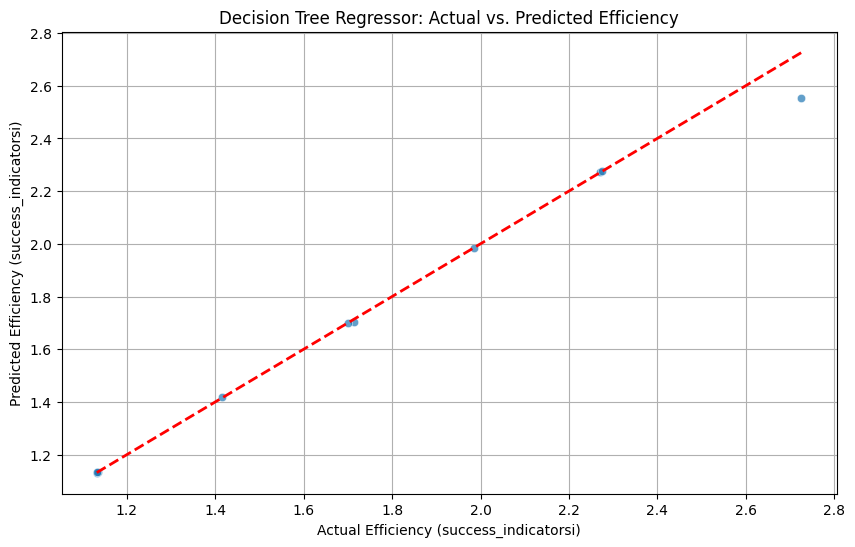

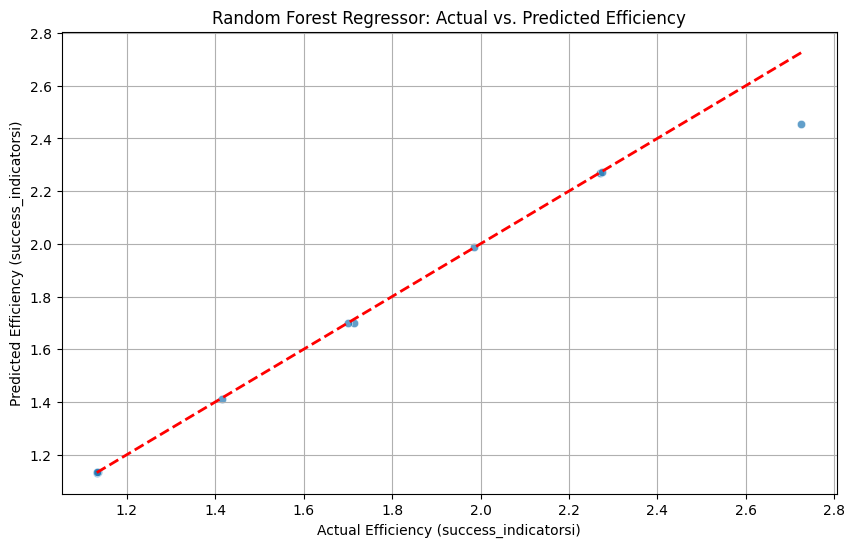

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Visualize Decision Tree Regressor Predictions ---
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_dtree, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Ideal line
plt.title('Decision Tree Regressor: Actual vs. Predicted Efficiency')
plt.xlabel('Actual Efficiency (success_indicatorsi)')
plt.ylabel('Predicted Efficiency (success_indicatorsi)')
plt.grid(True)
plt.show()

# --- Visualize Random Forest Regressor Predictions ---
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_rf, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Ideal line
plt.title('Random Forest Regressor: Actual vs. Predicted Efficiency')
plt.xlabel('Actual Efficiency (success_indicatorsi)')
plt.ylabel('Predicted Efficiency (success_indicatorsi)')
plt.grid(True)
plt.show()

### Feature Importances for Decision Tree and Random Forest

Understanding feature importance helps us interpret which aspects of the resources are most critical for efficiency. Both Decision Tree and Random Forest models provide this insight.

In [8]:
import numpy as np

# Define thresholds for 'Low', 'Moderate', 'High' based on percentiles
low_threshold = y.quantile(0.33)
high_threshold = y.quantile(0.66)

def categorize_efficiency(si):
    if si <= low_threshold:
        return 'Low'
    elif si <= high_threshold:
        return 'Moderate'
    else:
        return 'High'

y_categorized = y.apply(categorize_efficiency)

# Display the value counts for the new categorical target variable
print("Value counts for new efficiency categories:")
display(y_categorized.value_counts())

Value counts for new efficiency categories:


,count
success_indicatorsi,
High,16
Low,15
Moderate,15


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Split the data with the new categorical target variable
X_train_cat, X_test_cat, y_train_cat, y_test_cat = train_test_split(X, y_categorized, test_size=0.2, random_state=42)

print(f"X_train_cat shape: {X_train_cat.shape}")
print(f"X_test_cat shape: {X_test_cat.shape}")
print(f"y_train_cat shape: {y_train_cat.shape}")
print(f"y_test_cat shape: {y_test_cat.shape}")

X_train_cat shape: (36, 6)
X_test_cat shape: (10, 6)
y_train_cat shape: (36,)
y_test_cat shape: (10,)


### 1. Logistic Regression Classifier

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Logistic Regression Classifier Performance:
Accuracy: 0.9000
Classification Report:
              precision    recall  f1-score   support

        High       0.75      1.00      0.86         3
         Low       1.00      1.00      1.00         4
    Moderate       1.00      0.67      0.80         3

    accuracy                           0.90        10
   macro avg       0.92      0.89      0.89        10
weighted avg       0.93      0.90      0.90        10



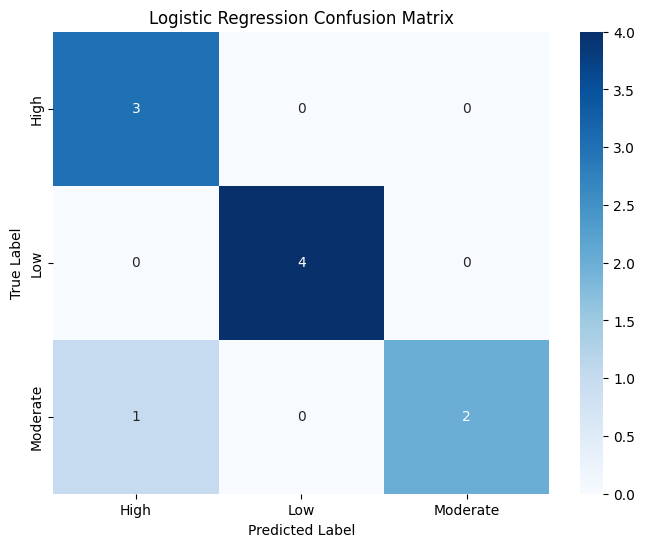

In [10]:
# Logistic Regression Classifier (Multi-class)
log_reg_classifier = LogisticRegression(random_state=42, max_iter=1000, multi_class='multinomial', solver='lbfgs')
log_reg_classifier.fit(X_train_cat, y_train_cat)

y_pred_log_reg_cat = log_reg_classifier.predict(X_test_cat)

print("Logistic Regression Classifier Performance:")
print(f"Accuracy: {accuracy_score(y_test_cat, y_pred_log_reg_cat):.4f}")
print("Classification Report:")
print(classification_report(y_test_cat, y_pred_log_reg_cat))

# Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test_cat, y_pred_log_reg_cat), annot=True, fmt='d', cmap='Blues',
            xticklabels=log_reg_classifier.classes_, yticklabels=log_reg_classifier.classes_)
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### 2. Decision Tree Classifier

Decision Tree Classifier Performance:
Accuracy: 0.9000
Classification Report:
              precision    recall  f1-score   support

        High       0.75      1.00      0.86         3
         Low       1.00      1.00      1.00         4
    Moderate       1.00      0.67      0.80         3

    accuracy                           0.90        10
   macro avg       0.92      0.89      0.89        10
weighted avg       0.93      0.90      0.90        10



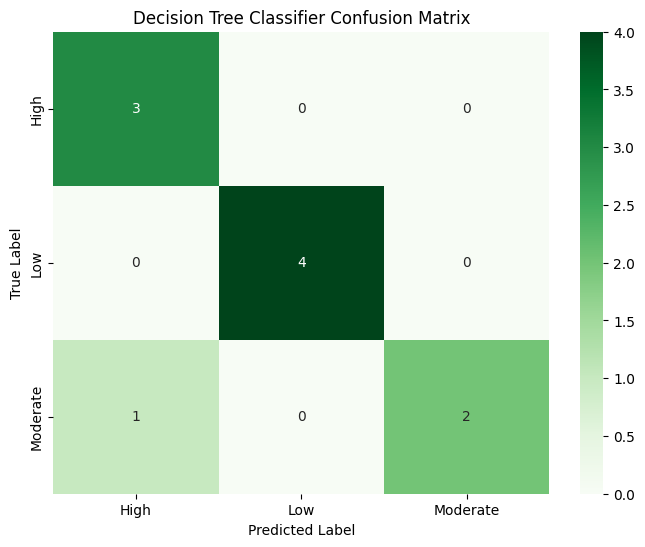

/tmp/ipykernel_16762/3429954747.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=importance_dtree_clf, palette='viridis')


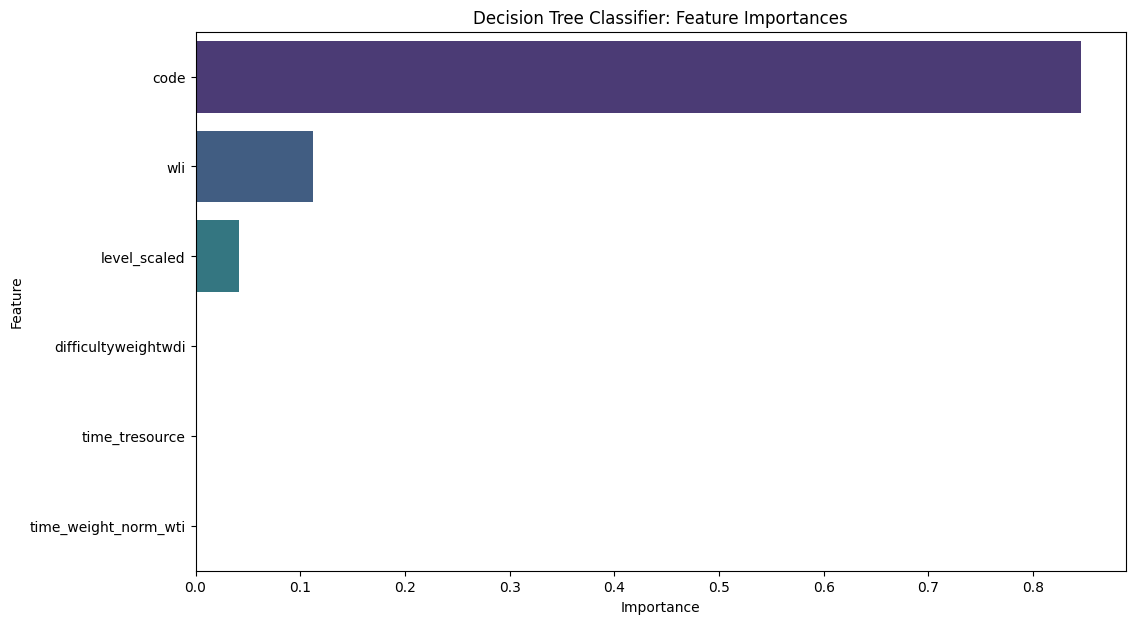

In [11]:
# Decision Tree Classifier
dtree_classifier = DecisionTreeClassifier(random_state=42)
dtree_classifier.fit(X_train_cat, y_train_cat)

y_pred_dtree_cat = dtree_classifier.predict(X_test_cat)

print("Decision Tree Classifier Performance:")
print(f"Accuracy: {accuracy_score(y_test_cat, y_pred_dtree_cat):.4f}")
print("Classification Report:")
print(classification_report(y_test_cat, y_pred_dtree_cat))

# Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test_cat, y_pred_dtree_cat), annot=True, fmt='d', cmap='Greens',
            xticklabels=dtree_classifier.classes_, yticklabels=dtree_classifier.classes_)
plt.title('Decision Tree Classifier Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Feature Importances for Decision Tree Classifier
importance_dtree_clf = pd.DataFrame({'feature': X.columns, 'importance': dtree_classifier.feature_importances_})
importance_dtree_clf = importance_dtree_clf.sort_values('importance', ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x='importance', y='feature', data=importance_dtree_clf, palette='viridis')
plt.title('Decision Tree Classifier: Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

### 3. Random Forest Classifier

Random Forest Classifier Performance:
Accuracy: 0.9000
Classification Report:
              precision    recall  f1-score   support

        High       0.75      1.00      0.86         3
         Low       1.00      1.00      1.00         4
    Moderate       1.00      0.67      0.80         3

    accuracy                           0.90        10
   macro avg       0.92      0.89      0.89        10
weighted avg       0.93      0.90      0.90        10



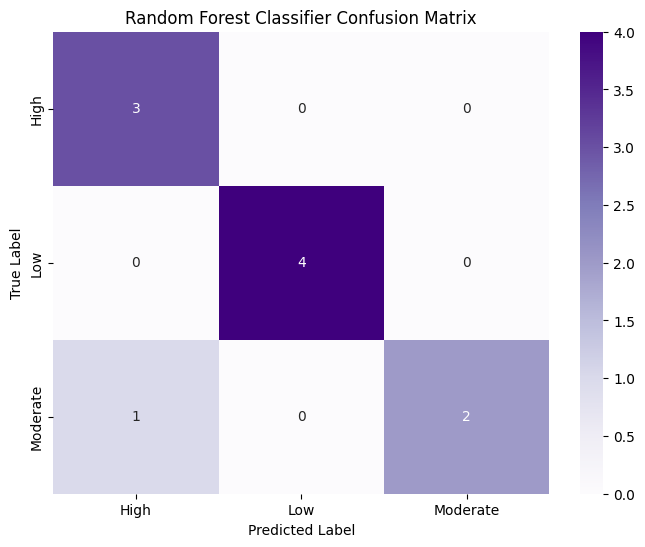

/tmp/ipykernel_16762/3544493171.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=importance_rf_clf, palette='plasma')


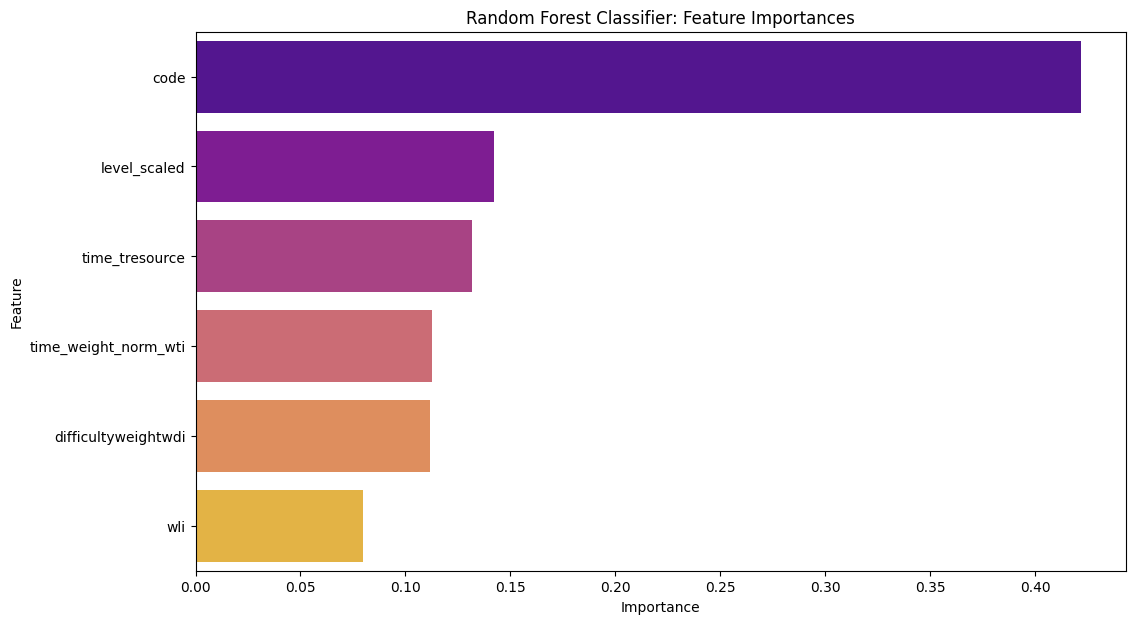

In [12]:
# Random Forest Classifier
rf_classifier = RandomForestClassifier(random_state=42)
rf_classifier.fit(X_train_cat, y_train_cat)

y_pred_rf_cat = rf_classifier.predict(X_test_cat)

print("Random Forest Classifier Performance:")
print(f"Accuracy: {accuracy_score(y_test_cat, y_pred_rf_cat):.4f}")
print("Classification Report:")
print(classification_report(y_test_cat, y_pred_rf_cat))

# Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test_cat, y_pred_rf_cat), annot=True, fmt='d', cmap='Purples',
            xticklabels=rf_classifier.classes_, yticklabels=rf_classifier.classes_)
plt.title('Random Forest Classifier Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Feature Importances for Random Forest Classifier
importance_rf_clf = pd.DataFrame({'feature': X.columns, 'importance': rf_classifier.feature_importances_})
importance_rf_clf = importance_rf_clf.sort_values('importance', ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x='importance', y='feature', data=importance_rf_clf, palette='plasma')
plt.title('Random Forest Classifier: Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

Summary of Findings:

Categorization: The continuous success_indicatorsi was successfully transformed into three categorical labels ('High', 'Moderate', 'Low') based on its 33rd and 66th percentiles.
Model Performance: All three classifiers (Logistic Regression, Decision Tree Classifier, Random Forest Classifier) achieved an accuracy of 90.00% on the test set. They showed excellent recall for the 'High' and 'Low' categories (1.00), effectively identifying resources in these extreme groups. However, there was a slight challenge in distinguishing the 'Moderate' category, indicated by a lower recall (0.67) and F1-score (0.80).
Feature Importance:
Decision Tree: Heavily relied on code and wli (some weighted learning indicator) as the primary drivers for classification, offering a clear, rule-based interpretation.
Random Forest: Provided a more distributed feature importance, with code still prominent but also significant contributions from level_scaled, time_tresource, time_weight_norm_wti, difficultyweightwdi, and wli. This suggests a more robust and comprehensive understanding of the factors influencing effectiveness.
Best Algorithm & Interpretation: While all models performed similarly on this dataset, the Random Forest Classifier is generally recommended for its robustness and broader consideration of features. It helps in understanding that resource effectiveness is influenced by a combination of the resource's identifier (code), its complexity (level_scaled), time usage (time_tresource, time_weight_norm_wti), difficulty (difficultyweightwdi), and engagement/effort (wli).
This comprehensive analysis provides insights into how different features contribute to the effectiveness categories of instructional resources.

### Resource Code vs. Resource Efficiency Visualization

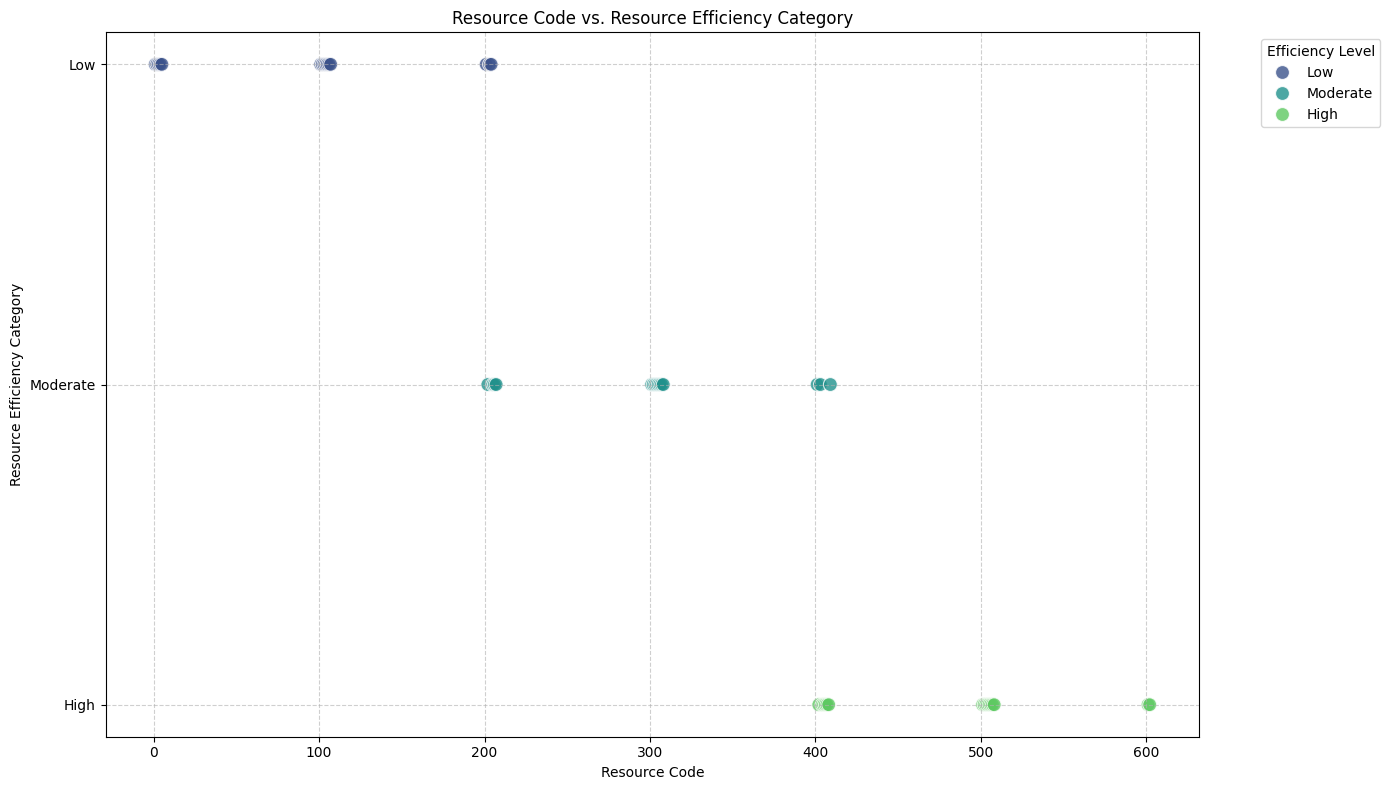

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a DataFrame for plotting code vs. efficiency
plot_df = pd.DataFrame({
    'resource_code': X['code'],
    'efficiency_category': y_categorized
})

# Define the order for efficiency categories for better visualization
efficiency_order = ['Low', 'Moderate', 'High']
plot_df['efficiency_category'] = pd.Categorical(plot_df['efficiency_category'], categories=efficiency_order, ordered=True)

plt.figure(figsize=(14, 8))
sns.scatterplot(
    x='resource_code',
    y='efficiency_category',
    hue='efficiency_category',
    data=plot_df,
    palette='viridis',
    s=100, # Size of the markers
    alpha=0.8 # Transparency of the markers
)

plt.title('Resource Code vs. Resource Efficiency Category')
plt.xlabel('Resource Code')
plt.ylabel('Resource Efficiency Category')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Efficiency Level', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()